1. LOAD + FEATURE SETUP

Artifact directory ready: /content/artifacts/hssc_5fold_cv

Loaded datasets:
Train: 1429
Validation: 306
Test: 307

Class distribution:
Train: {0: 726, 1: 703}
Validation: {0: 155, 1: 151}
Test: {0: 156, 1: 151}

Number of features: 32
['title_len_chars', 'title_len_words', 'has_exclamation', 'has_question_mark', 'has_quotes', 'has_number', 'has_caps', 'caps_count', 'uppercase_ratio', 'has_question_signal', 'has_negation_signal', 'has_topic_signal', 'has_any_signal', 'has_multi_signal', 'has_all_three_signals', 'short_title_flag', 'title_signal_score', 'text_len_chars', 'text_len_words', 'has_debunking_signal', 'has_source_reference_signal', 'has_topic_signal_text', 'has_any_text_signal', 'has_multi_text_signal', 'has_all_three_text_signals', 'debunking_match_count', 'source_reference_match_count', 'topic_match_count', 'signal_match_total', 'signal_density', 'text_signal_score', 'semantic_signal']

STARTING FOLD 1/5

STARTING FOLD 2/5

STARTING FOLD 3/5

STARTING FOLD 4/5

STARTING FOL

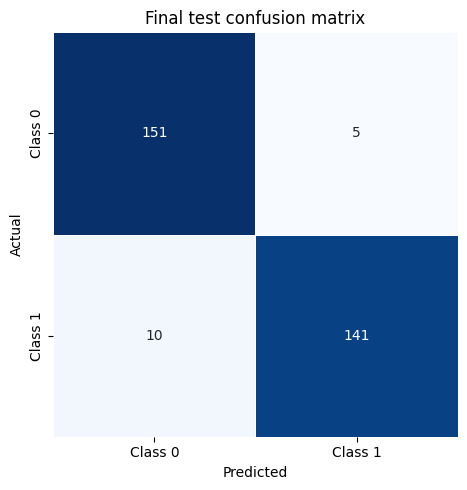

Final confusion matrix saved: /content/artifacts/hssc_5fold_cv/final_test_confusion_matrix.png


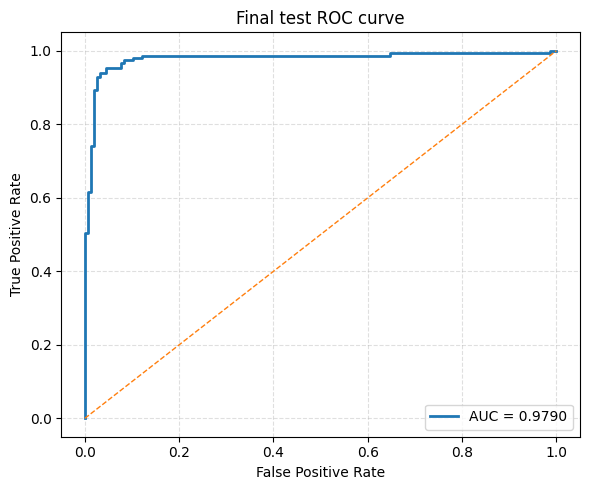

Final ROC curve saved: /content/artifacts/hssc_5fold_cv/final_test_roc_curve.png

HSSC 5-fold CV experiment finished successfully.
You now have:
- 5-fold CV fold results
- CV summary statistics
- CV all predictions
- final trained model
- final test metrics JSON
- final classification report
- final test prediction CSV
- final confusion matrix PNG
- final ROC curve PNG
- for_semantic_signal_building folder
  - hssc_train_predictions.csv
  - hssc_validation_predictions.csv
  - hssc_test_predictions.csv


In [ ]:
import os
import json
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# =========================================================
# 0) SETTINGS
# =========================================================
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

TRAIN_PATH = "/content/train_hssc_features.csv"
VAL_PATH = "/content/validation_hssc_features.csv"
TEST_PATH = "/content/test_hssc_features.csv"

TITLE_COL = "title"
TEXT_COL = "full_text"
LABEL_COL = "class_label"

MODEL_NAME = "hssc_5fold_cv"
ARTIFACT_DIR = f"/content/artifacts/{MODEL_NAME}"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(ARTIFACT_DIR, "final_model.pkl")
CV_RESULTS_PATH = os.path.join(ARTIFACT_DIR, "cv_fold_results.csv")
CV_SUMMARY_PATH = os.path.join(ARTIFACT_DIR, "cv_summary_statistics.csv")
CV_ALL_PRED_PATH = os.path.join(ARTIFACT_DIR, "cv_all_predictions.csv")

FINAL_PREDICTIONS_PATH = os.path.join(ARTIFACT_DIR, "final_test_predictions.csv")
FINAL_METRICS_JSON_PATH = os.path.join(ARTIFACT_DIR, "final_test_metrics.json")
FINAL_REPORT_PATH = os.path.join(ARTIFACT_DIR, "final_test_classification_report.txt")
FINAL_CONFUSION_MATRIX_PATH = os.path.join(ARTIFACT_DIR, "final_test_confusion_matrix.png")
FINAL_ROC_PATH = os.path.join(ARTIFACT_DIR, "final_test_roc_curve.png")

SEMANTIC_DIR = os.path.join(ARTIFACT_DIR, "for_semantic_signal_building")
os.makedirs(SEMANTIC_DIR, exist_ok=True)

SEMANTIC_TRAIN_PRED_PATH = os.path.join(SEMANTIC_DIR, "hssc_train_predictions.csv")
SEMANTIC_VAL_PRED_PATH = os.path.join(SEMANTIC_DIR, "hssc_validation_predictions.csv")
SEMANTIC_TEST_PRED_PATH = os.path.join(SEMANTIC_DIR, "hssc_test_predictions.csv")

N_FOLDS = 5

print("Artifact directory ready:", ARTIFACT_DIR)

# =========================================================
# 1) LOAD DATA
# =========================================================
train_df = pd.read_csv(TRAIN_PATH).reset_index(drop=True)
val_df = pd.read_csv(VAL_PATH).reset_index(drop=True)
test_df = pd.read_csv(TEST_PATH).reset_index(drop=True)

print("\nLoaded datasets:")
print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")

print("\nClass distribution:")
print("Train:", train_df[LABEL_COL].value_counts().to_dict())
print("Validation:", val_df[LABEL_COL].value_counts().to_dict())
print("Test:", test_df[LABEL_COL].value_counts().to_dict())

# ---------------------------------------------------------
# FEATURE COLUMNS
# ---------------------------------------------------------
EXCLUDE_COLS = [
    "title",
    "full_text",
    "title_clean",
    "full_text_clean",
    "class_label",
]

FEATURES = [c for c in train_df.columns if c not in EXCLUDE_COLS]

print("\nNumber of features:", len(FEATURES))
print(FEATURES)

# combine train + validation for CV
trainval_df = pd.concat([train_df, val_df], ignore_index=True)
X_trainval = trainval_df[FEATURES].copy()
y_trainval = trainval_df[LABEL_COL].astype(int).values

X_test = test_df[FEATURES].copy()
y_test = test_df[LABEL_COL].astype(int).values

# =========================================================
# 2) HELPER FUNCTIONS
# =========================================================
def get_prediction_group(true_label, pred_label):
    if true_label == 1 and pred_label == 1:
        return "TP"
    elif true_label == 0 and pred_label == 0:
        return "TN"
    elif true_label == 0 and pred_label == 1:
        return "FP"
    elif true_label == 1 and pred_label == 0:
        return "FN"
    return "UNKNOWN"


def evaluate_model(y_true, y_pred, y_score):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_score)
    report_text = classification_report(y_true, y_pred, digits=4, zero_division=0)

    metrics_dict = {
        "accuracy": float(acc),
        "precision": float(p),
        "recall": float(r),
        "f1_score": float(f1),
        "roc_auc": float(roc_auc)
    }

    metrics_df = pd.DataFrame({
        "metric": ["accuracy", "precision", "recall", "f1_score", "roc_auc"],
        "value": [acc, p, r, f1, roc_auc]
    })

    return metrics_dict, metrics_df, cm, report_text


def save_prediction_results(df_input, y_true, y_pred, y_prob, output_path):
    result_df = df_input.copy()

    result_df["pred_label"] = y_pred
    result_df["pred_prob"] = y_prob

    if TEXT_COL in result_df.columns:
        result_df["text_length"] = result_df[TEXT_COL].fillna("").astype(str).str.len()
    else:
        result_df["text_length"] = np.nan

    result_df["group"] = [
        get_prediction_group(t, p) for t, p in zip(y_true, y_pred)
    ]

    result_df.to_csv(output_path, index=False, encoding="utf-8")
    return result_df


def plot_confusion_matrix(cm, save_path):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Class 0", "Class 1"],
        yticklabels=["Class 0", "Class 1"],
        cbar=False,
        square=True,
        linewidths=0.5
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Final test confusion matrix")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_roc_curve(y_true, y_score, roc_auc, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_score)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], "--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Final test ROC curve")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def build_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_SEED
        ))
    ])


# =========================================================
# 3) 5-FOLD CROSS-VALIDATION ON TRAIN+VALIDATION
# =========================================================
skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_SEED
)

cv_fold_rows = []
cv_pred_frames = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), start=1):
    print("\n" + "=" * 70)
    print(f"STARTING FOLD {fold_idx}/{N_FOLDS}")

    X_fold_train = X_trainval.iloc[train_idx].copy()
    y_fold_train = y_trainval[train_idx]

    X_fold_val = X_trainval.iloc[val_idx].copy()
    y_fold_val = y_trainval[val_idx]

    fold_val_df = trainval_df.iloc[val_idx].copy().reset_index(drop=True)

    model = build_model()
    model.fit(X_fold_train, y_fold_train)

    fold_probs = model.predict_proba(X_fold_val)[:, 1]
    fold_preds = (fold_probs >= 0.5).astype(int)

    fold_metrics, _, _, _ = evaluate_model(
        y_true=y_fold_val,
        y_pred=fold_preds,
        y_score=fold_probs
    )

    fold_row = {
        "fold": fold_idx,
        "train_size": len(train_idx),
        "val_size": len(val_idx),
        **fold_metrics
    }
    cv_fold_rows.append(fold_row)

    fold_pred_df = fold_val_df.copy()
    fold_pred_df["fold"] = fold_idx
    fold_pred_df["pred_label"] = fold_preds
    fold_pred_df["pred_prob"] = fold_probs
    fold_pred_df["group"] = [
        get_prediction_group(t, p) for t, p in zip(y_fold_val, fold_preds)
    ]
    cv_pred_frames.append(fold_pred_df)

cv_results_df = pd.DataFrame(cv_fold_rows)
cv_results_df.to_csv(CV_RESULTS_PATH, index=False, encoding="utf-8")

cv_all_predictions_df = pd.concat(cv_pred_frames, ignore_index=True)
cv_all_predictions_df.to_csv(CV_ALL_PRED_PATH, index=False, encoding="utf-8")

cv_summary_df = pd.DataFrame([{
    "num_folds": N_FOLDS,
    "accuracy_mean": cv_results_df["accuracy"].mean(),
    "accuracy_std": cv_results_df["accuracy"].std(ddof=1),
    "precision_mean": cv_results_df["precision"].mean(),
    "precision_std": cv_results_df["precision"].std(ddof=1),
    "recall_mean": cv_results_df["recall"].mean(),
    "recall_std": cv_results_df["recall"].std(ddof=1),
    "f1_mean": cv_results_df["f1_score"].mean(),
    "f1_std": cv_results_df["f1_score"].std(ddof=1),
    "roc_auc_mean": cv_results_df["roc_auc"].mean(),
    "roc_auc_std": cv_results_df["roc_auc"].std(ddof=1)
}])
cv_summary_df.to_csv(CV_SUMMARY_PATH, index=False, encoding="utf-8")

print("\n=== 5-FOLD CV RESULTS ===")
print(cv_results_df.sort_values("f1_score", ascending=False).to_string(index=False))

print("\n=== 5-FOLD CV SUMMARY ===")
print(cv_summary_df.to_string(index=False))

# =========================================================
# 4) FINAL TRAINING ON ALL TRAIN+VALIDATION
# =========================================================
final_model = build_model()
final_model.fit(X_trainval, y_trainval)

with open(MODEL_PATH, "wb") as f:
    pickle.dump(final_model, f)

print(f"\nSaved final model: {MODEL_PATH}")

# =========================================================
# 5) FINAL TEST EVALUATION
# =========================================================
test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

metrics_dict, metrics_df, cm, report_text = evaluate_model(
    y_true=y_test,
    y_pred=test_preds,
    y_score=test_probs
)

print("\n=== FINAL TEST RESULTS ===")
print(metrics_df.to_string(index=False))

print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

print("\nClassification report:")
print(report_text)

# =========================================================
# 6) SAVE FINAL METRICS + REPORT
# =========================================================
with open(FINAL_METRICS_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=2)

with open(FINAL_REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(report_text)

print("\nSaved files:")
print(f"Final metrics JSON: {FINAL_METRICS_JSON_PATH}")
print(f"Final classification report: {FINAL_REPORT_PATH}")

# =========================================================
# 7) SAVE PREDICTIONS
# =========================================================
final_test_results_df = save_prediction_results(
    df_input=test_df,
    y_true=y_test,
    y_pred=test_preds,
    y_prob=test_probs,
    output_path=FINAL_PREDICTIONS_PATH
)

# predictions for semantic signal building
X_train = train_df[FEATURES].copy()
y_train = train_df[LABEL_COL].astype(int).values
train_probs = final_model.predict_proba(X_train)[:, 1]
train_preds = (train_probs >= 0.5).astype(int)

X_val = val_df[FEATURES].copy()
y_val = val_df[LABEL_COL].astype(int).values
val_probs = final_model.predict_proba(X_val)[:, 1]
val_preds = (val_probs >= 0.5).astype(int)

save_prediction_results(
    df_input=train_df,
    y_true=y_train,
    y_pred=train_preds,
    y_prob=train_probs,
    output_path=SEMANTIC_TRAIN_PRED_PATH
)

save_prediction_results(
    df_input=val_df,
    y_true=y_val,
    y_pred=val_preds,
    y_prob=val_probs,
    output_path=SEMANTIC_VAL_PRED_PATH
)

save_prediction_results(
    df_input=test_df,
    y_true=y_test,
    y_pred=test_preds,
    y_prob=test_probs,
    output_path=SEMANTIC_TEST_PRED_PATH
)

print(f"\nFinal prediction file saved: {FINAL_PREDICTIONS_PATH}")
print(f"Semantic train predictions saved: {SEMANTIC_TRAIN_PRED_PATH}")
print(f"Semantic validation predictions saved: {SEMANTIC_VAL_PRED_PATH}")
print(f"Semantic test predictions saved: {SEMANTIC_TEST_PRED_PATH}")

print("\nPrediction file preview:")
print(final_test_results_df.head().to_string(index=False))

# =========================================================
# 8) PLOT + SAVE FINAL CONFUSION MATRIX
# =========================================================
plot_confusion_matrix(cm, FINAL_CONFUSION_MATRIX_PATH)
print(f"Final confusion matrix saved: {FINAL_CONFUSION_MATRIX_PATH}")

# =========================================================
# 9) PLOT + SAVE FINAL ROC CURVE
# =========================================================
plot_roc_curve(
    y_true=y_test,
    y_score=test_probs,
    roc_auc=metrics_dict["roc_auc"],
    save_path=FINAL_ROC_PATH
)
print(f"Final ROC curve saved: {FINAL_ROC_PATH}")

# =========================================================
# 10) FINAL MESSAGE
# =========================================================
print("\nHSSC 5-fold CV experiment finished successfully.")
print("You now have:")
print("- 5-fold CV fold results")
print("- CV summary statistics")
print("- CV all predictions")
print("- final trained model")
print("- final test metrics JSON")
print("- final classification report")
print("- final test prediction CSV")
print("- final confusion matrix PNG")
print("- final ROC curve PNG")
print("- for_semantic_signal_building folder")
print("  - hssc_train_predictions.csv")
print("  - hssc_validation_predictions.csv")
print("  - hssc_test_predictions.csv")

In [ ]:
import pandas as pd

# Ceļš uz HSSC rezultātu failu
df = pd.read_csv("/content/artifacts/hssc_5fold_cv/final_test_predictions.csv")

# Pielāgo kolonnu nosaukumus, ja vajag
true_col = "class_label"
pred_col = "pred_label"

# False Positives: true = 0, predicted = 1
fp_df = df[(df[true_col] == 0) & (df[pred_col] == 1)]

# False Negatives: true = 1, predicted = 0
fn_df = df[(df[true_col] == 1) & (df[pred_col] == 0)]

print("FP indices:")
print(fp_df.index.tolist())

print("\nFN indices:")
print(fn_df.index.tolist())

FP indices:
[49, 100, 206, 248, 273]

FN indices:
[17, 38, 71, 87, 94, 154, 161, 209, 229, 264]


In [ ]:
import shutil

source_folder = "/content/artifacts/hssc_5fold_cv"
output_zip = "/content/hssc_5fold_cv_results"

shutil.make_archive(output_zip, "zip", source_folder)

print("ZIP izveidots:", output_zip + ".zip")

ZIP izveidots: /content/hssc_5fold_cv_results.zip


5. INTERPRETABILITY (ĻOTI SVARĪGI)

In [ ]:
print(len(FEATURES))

32


In [ ]:
import numpy as np
import pandas as pd

coef = model.named_steps["clf"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

print("\nFEATURES:\n")
print(feature_importance.head(32))


FEATURES:

                         feature      coef  abs_coef
31               semantic_signal  2.869941  2.869941
26  source_reference_match_count  0.879210  0.879210
28            signal_match_total  0.637836  0.637836
23         has_multi_text_signal  0.591324  0.591324
30             text_signal_score  0.498839  0.498839
18                text_len_words -0.464561  0.464561
12                has_any_signal  0.428007  0.428007
22           has_any_text_signal -0.363176  0.363176
25         debunking_match_count -0.358601  0.358601
27             topic_match_count  0.337976  0.337976
11              has_topic_signal  0.333772  0.333772
24    has_all_three_text_signals  0.312993  0.312993
16            title_signal_score  0.301841  0.301841
10           has_negation_signal  0.246496  0.246496
29                signal_density  0.233424  0.233424
4                     has_quotes  0.233404  0.233404
0                title_len_chars -0.230118  0.230118
2                has_exclamation -

Feature importance analysis of the HSSC model reveals that the most influential predictor is the semantic_signal derived from the LVBERT transformer model, with a substantially higher coefficient than all other features. This confirms that contextual semantic understanding plays a central role in the classification task.

However, several interpretable rule-based features also demonstrate strong contributions. In particular, signal_match_total, source_reference_match_count, and topic_match_count show high positive coefficients, indicating that articles containing structured references, topical keywords, and aggregated signal patterns are more likely to belong to the misinformation-related class.

Question-based signals (has_question_signal) and stylistic indicators such as quotation usage and capitalization also contribute positively, reflecting the characteristic interrogative and attention-driven structure of misinformation-related headlines.

Conversely, certain features exhibit negative coefficients. For example, longer texts (text_len_words) are associated with factual reporting, suggesting that more extensive and detailed articles tend to belong to the reliable class. Similarly, debunking_match_count contributes negatively, indicating that explicit debunking language is more characteristic of fact-checking or corrective content.

Overall, the results demonstrate that while the transformer-based semantic signal is the dominant feature, the inclusion of interpretable linguistic and stylistic signals significantly enhances the model’s ability to capture structural patterns of misinformation-related discourse.

In [ ]:
import pandas as pd

# ---------------------------------------
# CREATE DF
# ---------------------------------------
feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "coef": model.named_steps["clf"].coef_[0]
})

feature_importance["abs_coef"] = feature_importance["coef"].abs()

# ---------------------------------------
# DEFINE GROUPS
# ---------------------------------------
def get_group(feature):
    if feature == "semantic_signal":
        return "semantic"

    elif "title" in feature or feature in [
        "has_exclamation", "has_question_mark", "has_quotes",
        "has_number", "has_caps", "caps_count", "uppercase_ratio",
        "has_question_signal", "has_negation_signal", "has_topic_signal",
        "has_any_signal", "has_multi_signal", "has_all_three_signals",
        "short_title_flag"
    ]:
        return "title"

    else:
        return "text"

feature_importance["group"] = feature_importance["feature"].apply(get_group)

# ---------------------------------------
# SUMMARY
# ---------------------------------------
group_summary = feature_importance.groupby("group").agg({
    "feature": "count",
    "abs_coef": "mean",
    "coef": "sum"
}).rename(columns={
    "feature": "num_features",
    "abs_coef": "avg_importance",
    "coef": "total_effect"
}).sort_values("avg_importance", ascending=False)

print(group_summary)

          num_features  avg_importance  total_effect
group                                               
semantic             1        2.869941      2.869941
text                14        0.361693      2.691022
title               17        0.179602      1.460058


In [ ]:
import plotly.express as px

# Rename group labels for display
feature_importance_plot = feature_importance.copy()
feature_importance_plot["group"] = feature_importance_plot["group"].replace({
    "title": "Intensity signal (title)",
    "text": "Framing signal (text)",
    "semantic": "Semantic signal"
})

# Aggregate mean importance by group
plot_df = (
    feature_importance_plot
    .groupby("group", as_index=False)["abs_coef"]
    .mean()
)

fig = px.bar(
    plot_df,
    x="group",
    y="abs_coef",
    text="abs_coef",
    title="Average feature importance by group"
)

fig.update_traces(
    marker_color="#1f77b4",
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Feature Group",
    yaxis_title="Average |Coefficient|",
    template="plotly_white"
)

fig.show()

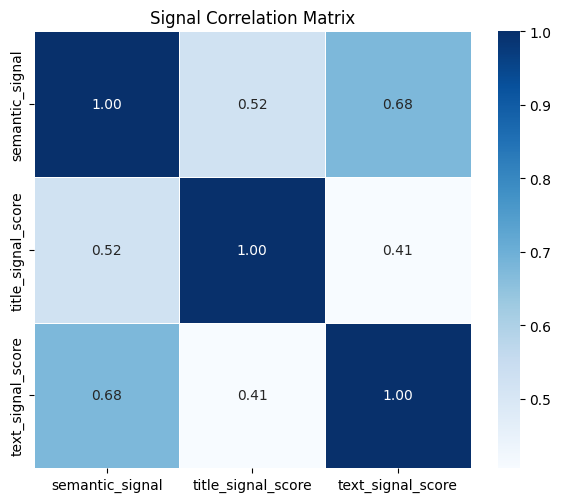

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# izvēlies feature kolonnas
corr_features = [
    "semantic_signal",
    "title_signal_score",
    "text_signal_score"
]

corr = test_df[corr_features].corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",   # 🔵 zilā krāsa
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Signal Correlation Matrix")
plt.tight_layout()
plt.show()

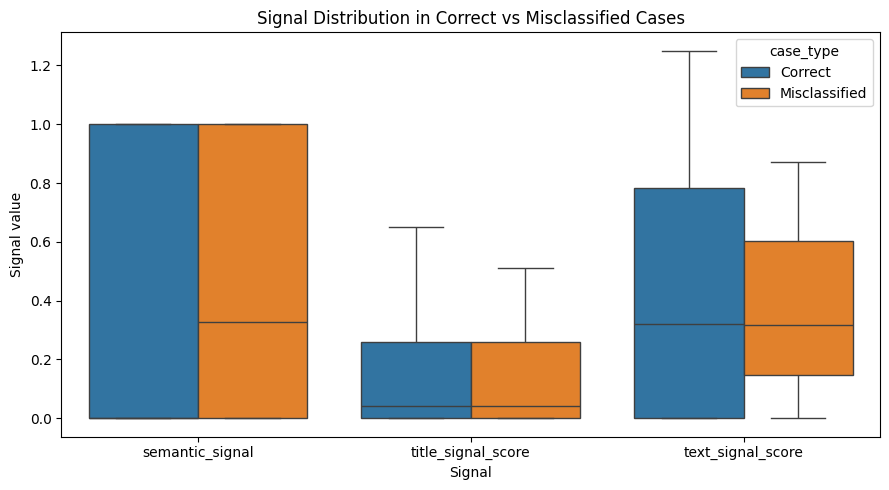

            signal     case_type  count     mean   median      std      min      max
   semantic_signal       Correct    292 0.483843 0.001766 0.499581 0.000104 0.999828
   semantic_signal Misclassified     15 0.482829 0.325550 0.495214 0.000283 0.999804
 text_signal_score       Correct    292 0.414269 0.321633 0.431359 0.000000 1.250000
 text_signal_score Misclassified     15 0.377837 0.317452 0.308940 0.000000 0.870000
title_signal_score       Correct    292 0.166440 0.040000 0.216947 0.000000 0.920000
title_signal_score Misclassified     15 0.161333 0.040000 0.204795 0.000000 0.510000

Saved plot: /content/hssc_signal_distribution_correct_vs_misclassified.png
Saved stats: /content/hssc_signal_distribution_correct_vs_misclassified_stats.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PREDICTIONS_FILE = "/content/artifacts/hssc_5fold_cv/final_test_predictions.csv"
SAVE_PATH = "/content/hssc_signal_distribution_correct_vs_misclassified.png"
STATS_PATH = "/content/hssc_signal_distribution_correct_vs_misclassified_stats.csv"

df = pd.read_csv(PREDICTIONS_FILE)

# create correctness label
df["case_type"] = df["group"].apply(
    lambda x: "Correct" if x in ["TP", "TN"] else "Misclassified"
)

signal_cols = ["semantic_signal", "title_signal_score", "text_signal_score"]

plot_df = df[["case_type"] + signal_cols].melt(
    id_vars="case_type",
    value_vars=signal_cols,
    var_name="signal",
    value_name="value"
)

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=plot_df,
    x="signal",
    y="value",
    hue="case_type",
    showfliers=False
)

plt.title("Signal Distribution in Correct vs Misclassified Cases")
plt.xlabel("Signal")
plt.ylabel("Signal value")
plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")
plt.show()

summary = (
    plot_df.groupby(["signal", "case_type"])["value"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .reset_index()
)

summary.to_csv(STATS_PATH, index=False, encoding="utf-8")

print(summary.to_string(index=False))
print("\nSaved plot:", SAVE_PATH)
print("Saved stats:", STATS_PATH)

The correlation analysis shows that while semantic and rule-based signals are moderately correlated, they are not redundant. This indicates that the transformer-based semantic representation captures additional contextual information beyond surface-level linguistic patterns.

The results support the effectiveness of the hybrid approach, where combining semantic and interpretable signals provides complementary information rather than duplicating the same features.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

rows = []

for th in thresholds:
    val_preds_th = (val_probs >= th).astype(int)

    rows.append({
        "threshold": round(float(th), 2),
        "accuracy": accuracy_score(y_val, val_preds_th),
        "precision": precision_score(y_val, val_preds_th, zero_division=0),
        "recall": recall_score(y_val, val_preds_th, zero_division=0),
        "f1_score": f1_score(y_val, val_preds_th, zero_division=0),
    })

threshold_results = pd.DataFrame(rows)

print("THRESHOLD EXPERIMENT (VALIDATION)\n")
print(threshold_results)

best_row = threshold_results.sort_values(
    ["f1_score", "accuracy"], ascending=False
).iloc[0]

best_threshold = float(best_row["threshold"])

print("\nBEST THRESHOLD BASED ON VALIDATION F1:")
print(best_row)
print(f"\nSelected threshold: {best_threshold:.2f}")

THRESHOLD EXPERIMENT (VALIDATION)

    threshold  accuracy  precision    recall  f1_score
0        0.10  0.957516   0.948052  0.966887  0.957377
1        0.15  0.960784   0.960265  0.960265  0.960265
2        0.20  0.964052   0.966667  0.960265  0.963455
3        0.25  0.964052   0.966667  0.960265  0.963455
4        0.30  0.967320   0.973154  0.960265  0.966667
5        0.35  0.967320   0.973154  0.960265  0.966667
6        0.40  0.964052   0.972973  0.953642  0.963211
7        0.45  0.964052   0.972973  0.953642  0.963211
8        0.50  0.964052   0.979452  0.947020  0.962963
9        0.55  0.960784   0.979310  0.940397  0.959459
10       0.60  0.960784   0.979310  0.940397  0.959459
11       0.65  0.957516   0.979167  0.933775  0.955932
12       0.70  0.957516   0.979167  0.933775  0.955932
13       0.75  0.957516   0.979167  0.933775  0.955932
14       0.80  0.957516   0.979167  0.933775  0.955932
15       0.85  0.950980   0.978873  0.920530  0.948805
16       0.90  0.931373   0.97

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

test_preds_best = (test_probs >= best_threshold).astype(int)

print("TEST REPORT WITH BEST VALIDATION THRESHOLD:\n")
print(classification_report(y_test, test_preds_best, digits=4))

print("TEST ROC-AUC:", roc_auc_score(y_test, test_probs))

print("\nTEST HSSC CONFUSION MATRIX:")
print(confusion_matrix(y_test, test_preds_best))

TEST REPORT WITH BEST VALIDATION THRESHOLD:

              precision    recall  f1-score   support

           0     0.9551    0.9551    0.9551       156
           1     0.9536    0.9536    0.9536       151

    accuracy                         0.9544       307
   macro avg     0.9544    0.9544    0.9544       307
weighted avg     0.9544    0.9544    0.9544       307

TEST ROC-AUC: 0.9789862455425369

TEST HSSC CONFUSION MATRIX:
[[149   7]
 [  7 144]]


THRESHOLD EXPERIMENT (VALIDATION)

    threshold  accuracy  precision    recall  f1_score
0        0.10  0.957516   0.948052  0.966887  0.957377
1        0.15  0.960784   0.960265  0.960265  0.960265
2        0.20  0.964052   0.966667  0.960265  0.963455
3        0.25  0.964052   0.966667  0.960265  0.963455
4        0.30  0.967320   0.973154  0.960265  0.966667
5        0.35  0.967320   0.973154  0.960265  0.966667
6        0.40  0.964052   0.972973  0.953642  0.963211
7        0.45  0.964052   0.972973  0.953642  0.963211
8        0.50  0.964052   0.979452  0.947020  0.962963
9        0.55  0.960784   0.979310  0.940397  0.959459
10       0.60  0.960784   0.979310  0.940397  0.959459
11       0.65  0.957516   0.979167  0.933775  0.955932
12       0.70  0.957516   0.979167  0.933775  0.955932
13       0.75  0.957516   0.979167  0.933775  0.955932
14       0.80  0.957516   0.979167  0.933775  0.955932
15       0.85  0.950980   0.978873  0.920530  0.948805
16       0.90  0.931373   0.97

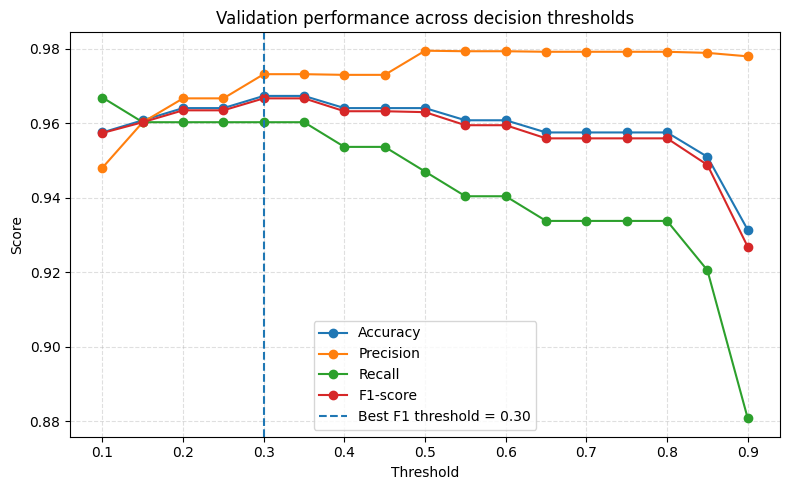

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --------------------------------------------------
# 1) Threshold sweep on validation
# --------------------------------------------------
thresholds = np.arange(0.10, 0.91, 0.05)

rows = []

for th in thresholds:
    val_preds_th = (val_probs >= th).astype(int)

    rows.append({
        "threshold": float(th),
        "accuracy": accuracy_score(y_val, val_preds_th),
        "precision": precision_score(y_val, val_preds_th, zero_division=0),
        "recall": recall_score(y_val, val_preds_th, zero_division=0),
        "f1_score": f1_score(y_val, val_preds_th, zero_division=0),
    })

threshold_results = pd.DataFrame(rows)

print("THRESHOLD EXPERIMENT (VALIDATION)\n")
print(threshold_results)

# --------------------------------------------------
# 2) Best threshold by F1
# --------------------------------------------------
best_row = threshold_results.sort_values(
    ["f1_score", "accuracy"],
    ascending=False
).iloc[0]

best_threshold = float(best_row["threshold"])

print("\nBEST THRESHOLD BASED ON VALIDATION F1:")
print(best_row)
print(f"\nSelected threshold: {best_threshold:.2f}")

# --------------------------------------------------
# 3) Plot
# --------------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(threshold_results["threshold"], threshold_results["accuracy"], marker="o", label="Accuracy")
plt.plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1_score"], marker="o", label="F1-score")

plt.axvline(best_threshold, linestyle="--", linewidth=1.5, label=f"Best F1 threshold = {best_threshold:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation performance across decision thresholds")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

A threshold tuning experiment was conducted on the validation set to optimize classification performance. While the default threshold of 0.5 already provided strong results, a slightly higher threshold of 0.55 yielded the best F1-score (0.9718), improving precision without reducing recall.

This indicates that a more conservative decision boundary helps reduce false positives while maintaining high detection performance.

Loaded:
Train: 1429
Validation: 306
Test: 307
=== VALIDATION TUNING RESULTS ===
 alpha  beta  val_accuracy  val_precision  val_recall   val_f1  val_roc_auc
  0.00  0.00      0.964052       0.972973    0.953642 0.963211     0.988079
  0.00  0.02      0.964052       0.972973    0.953642 0.963211     0.983807
  0.02  0.00      0.964052       0.972973    0.953642 0.963211     0.979919
  0.02  0.02      0.964052       0.972973    0.953642 0.963211     0.979427
  0.05  0.00      0.964052       0.972973    0.953642 0.963211     0.977633
  0.00  0.05      0.964052       0.972973    0.953642 0.963211     0.977505
  0.00  0.08      0.964052       0.972973    0.953642 0.963211     0.976565
  0.00  0.10      0.964052       0.972973    0.953642 0.963211     0.976394
  0.02  0.05      0.964052       0.972973    0.953642 0.963211     0.974151
  0.05  0.05      0.964052       0.972973    0.953642 0.963211     0.974108
  0.02  0.08      0.964052       0.972973    0.953642 0.963211     0.973980
  0.08  

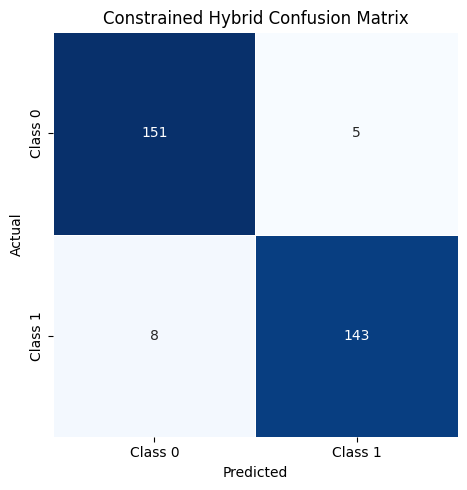

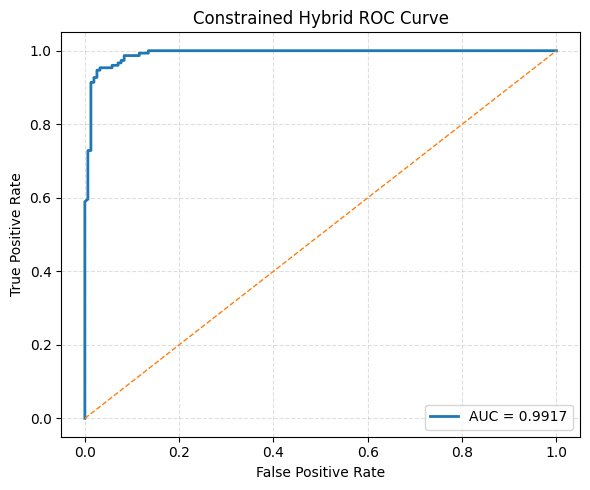


Saved:
/content/artifacts/constrained_hybrid_experiment/constrained_hybrid_tuning_results.csv
/content/artifacts/constrained_hybrid_experiment/constrained_hybrid_final_metrics.json
/content/artifacts/constrained_hybrid_experiment/constrained_hybrid_classification_report.txt
/content/artifacts/constrained_hybrid_experiment/constrained_hybrid_test_predictions.csv
/content/artifacts/constrained_hybrid_experiment/constrained_hybrid_confusion_matrix.png
/content/artifacts/constrained_hybrid_experiment/constrained_hybrid_roc_curve.png


In [ ]:
import os
import json
import numpy as np
import pandas as pd
from itertools import product
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 0) SETTINGS
# =========================================================
TRAIN_PATH = "/content/train_hssc_features.csv"
VAL_PATH = "/content/validation_hssc_features.csv"
TEST_PATH = "/content/test_hssc_features.csv"

LABEL_COL = "class_label"
LVBERT_PROB_COL = "semantic_signal"

# >>> PIELĀGO ŠOS NOSAUKUMUS SAVAM FAILAM <<<
CLICKBAIT_COL = "title_signal_score"
SENTIMENT_COL = "text_signal_score"

ARTIFACT_DIR = "/content/artifacts/constrained_hybrid_experiment"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

TUNING_RESULTS_PATH = os.path.join(ARTIFACT_DIR, "constrained_hybrid_tuning_results.csv")
FINAL_METRICS_PATH = os.path.join(ARTIFACT_DIR, "constrained_hybrid_final_metrics.json")
FINAL_REPORT_PATH = os.path.join(ARTIFACT_DIR, "constrained_hybrid_classification_report.txt")
FINAL_PREDICTIONS_PATH = os.path.join(ARTIFACT_DIR, "constrained_hybrid_test_predictions.csv")
CONFUSION_MATRIX_PATH = os.path.join(ARTIFACT_DIR, "constrained_hybrid_confusion_matrix.png")
ROC_PATH = os.path.join(ARTIFACT_DIR, "constrained_hybrid_roc_curve.png")

# small penalty search space
ALPHA_GRID = [0.00, 0.02, 0.05, 0.08, 0.10]
BETA_GRID  = [0.00, 0.02, 0.05, 0.08, 0.10]

THRESHOLD = 0.5

# =========================================================
# 1) LOAD DATA
# =========================================================
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

required_cols = [LABEL_COL, LVBERT_PROB_COL, CLICKBAIT_COL, SENTIMENT_COL]
for col in required_cols:
    if col not in train_df.columns:
        raise ValueError(f"Missing column in train file: {col}")
    if col not in val_df.columns:
        raise ValueError(f"Missing column in validation file: {col}")
    if col not in test_df.columns:
        raise ValueError(f"Missing column in test file: {col}")

print("Loaded:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# =========================================================
# 2) HELPERS
# =========================================================
def minmax_from_train(train_series, other_series):
    train_min = train_series.min()
    train_max = train_series.max()
    denom = train_max - train_min
    if denom == 0:
        return pd.Series(np.zeros(len(other_series)), index=other_series.index)
    return (other_series - train_min) / denom

def hybrid_probability(p_lvbert, cb_signal, s_signal, alpha, beta):
    p = p_lvbert - alpha * cb_signal - beta * s_signal
    return np.clip(p, 0.0, 1.0)

def evaluate(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    roc_auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=4, zero_division=0)
    return {
        "accuracy": float(acc),
        "precision": float(p),
        "recall": float(r),
        "f1_score": float(f1),
        "roc_auc": float(roc_auc),
        "confusion_matrix": cm,
        "report": report,
        "y_pred": y_pred,
    }

def save_predictions(df, y_prob, y_pred, output_path):
    out = df.copy()
    out["pred_prob"] = y_prob
    out["pred_label"] = y_pred
    out.to_csv(output_path, index=False, encoding="utf-8")

def plot_confusion_matrix(cm, save_path):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Class 0", "Class 1"],
        yticklabels=["Class 0", "Class 1"],
        cbar=False,
        square=True,
        linewidths=0.5
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Constrained Hybrid Confusion Matrix")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def plot_roc_curve(y_true, y_prob, roc_auc, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], "--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Constrained Hybrid ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# =========================================================
# 3) NORMALIZE AUXILIARY SIGNALS USING TRAIN STATS
# =========================================================
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["cb_norm"] = minmax_from_train(train_df[CLICKBAIT_COL], train_df[CLICKBAIT_COL])
val_df["cb_norm"] = minmax_from_train(train_df[CLICKBAIT_COL], val_df[CLICKBAIT_COL])
test_df["cb_norm"] = minmax_from_train(train_df[CLICKBAIT_COL], test_df[CLICKBAIT_COL])

train_df["sent_norm"] = minmax_from_train(train_df[SENTIMENT_COL], train_df[SENTIMENT_COL])
val_df["sent_norm"] = minmax_from_train(train_df[SENTIMENT_COL], val_df[SENTIMENT_COL])
test_df["sent_norm"] = minmax_from_train(train_df[SENTIMENT_COL], test_df[SENTIMENT_COL])

# =========================================================
# 4) TUNE ALPHA / BETA ON VALIDATION
# =========================================================
y_val = val_df[LABEL_COL].astype(int).values
val_rows = []

best_row = None

for alpha, beta in product(ALPHA_GRID, BETA_GRID):
    val_prob = hybrid_probability(
        p_lvbert=val_df[LVBERT_PROB_COL].astype(float).values,
        cb_signal=val_df["cb_norm"].astype(float).values,
        s_signal=val_df["sent_norm"].astype(float).values,
        alpha=alpha,
        beta=beta
    )

    metrics = evaluate(y_val, val_prob, threshold=THRESHOLD)

    row = {
        "alpha": alpha,
        "beta": beta,
        "val_accuracy": metrics["accuracy"],
        "val_precision": metrics["precision"],
        "val_recall": metrics["recall"],
        "val_f1": metrics["f1_score"],
        "val_roc_auc": metrics["roc_auc"]
    }
    val_rows.append(row)

    if best_row is None or row["val_f1"] > best_row["val_f1"]:
        best_row = row

tuning_df = pd.DataFrame(val_rows).sort_values(
    ["val_f1", "val_roc_auc"], ascending=[False, False]
)
tuning_df.to_csv(TUNING_RESULTS_PATH, index=False, encoding="utf-8")

print("=== VALIDATION TUNING RESULTS ===")
print(tuning_df.to_string(index=False))

print("\nBest parameters:")
print(best_row)

# =========================================================
# 5) FINAL TEST EVALUATION
# =========================================================
y_test = test_df[LABEL_COL].astype(int).values

test_prob = hybrid_probability(
    p_lvbert=test_df[LVBERT_PROB_COL].astype(float).values,
    cb_signal=test_df["cb_norm"].astype(float).values,
    s_signal=test_df["sent_norm"].astype(float).values,
    alpha=best_row["alpha"],
    beta=best_row["beta"]
)

final_metrics = evaluate(y_test, test_prob, threshold=THRESHOLD)

metrics_to_save = {
    "alpha": float(best_row["alpha"]),
    "beta": float(best_row["beta"]),
    "threshold": float(THRESHOLD),
    "accuracy": final_metrics["accuracy"],
    "precision": final_metrics["precision"],
    "recall": final_metrics["recall"],
    "f1_score": final_metrics["f1_score"],
    "roc_auc": final_metrics["roc_auc"]
}

print("\n=== FINAL TEST RESULTS ===")
print(pd.DataFrame({
    "metric": list(metrics_to_save.keys())[3:],
    "value": list(metrics_to_save.values())[3:]
}).to_string(index=False))

print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
print(final_metrics["confusion_matrix"])

print("\nClassification report:")
print(final_metrics["report"])

with open(FINAL_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics_to_save, f, ensure_ascii=False, indent=2)

with open(FINAL_REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(final_metrics["report"])

save_predictions(
    test_df,
    y_prob=test_prob,
    y_pred=final_metrics["y_pred"],
    output_path=FINAL_PREDICTIONS_PATH
)

plot_confusion_matrix(final_metrics["confusion_matrix"], CONFUSION_MATRIX_PATH)
plot_roc_curve(y_test, test_prob, final_metrics["roc_auc"], ROC_PATH)

print("\nSaved:")
print(TUNING_RESULTS_PATH)
print(FINAL_METRICS_PATH)
print(FINAL_REPORT_PATH)
print(FINAL_PREDICTIONS_PATH)
print(CONFUSION_MATRIX_PATH)
print(ROC_PATH)

# 1) Feature importance **interpretability**

In [ ]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# FEATURE IMPORTANCE TABLE
# --------------------------------------------------
coef = model.named_steps["clf"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

print("TOP 20 FEATURES:\n")
print(feature_importance.head(20))

print("\nTOP POSITIVE FEATURES (push toward class 1):\n")
print(feature_importance.sort_values("coef", ascending=False).head(10))

print("\nTOP NEGATIVE FEATURES (push toward class 0):\n")
print(feature_importance.sort_values("coef", ascending=True).head(10))

# --------------------------------------------------
# FEATURE GROUPING
# --------------------------------------------------
def get_group(feature):
    if feature == "semantic_signal":
        return "semantic"

    title_features = {
        "title_len_chars", "title_len_words", "has_exclamation",
        "has_question_mark", "has_quotes", "has_number", "has_caps",
        "caps_count", "uppercase_ratio", "has_question_signal",
        "has_negation_signal", "has_topic_signal", "has_any_signal",
        "has_multi_signal", "has_all_three_signals",
        "short_title_flag", "title_signal_score"
    }

    if feature in title_features:
        return "title"

    return "text"

feature_importance["group"] = feature_importance["feature"].apply(get_group)

group_summary = feature_importance.groupby("group").agg(
    num_features=("feature", "count"),
    avg_importance=("abs_coef", "mean"),
    total_effect=("abs_coef", "sum")
).sort_values("avg_importance", ascending=False)

print("\nFEATURE GROUP SUMMARY:\n")
print(group_summary)

TOP 20 FEATURES:

                         feature      coef  abs_coef
0                semantic_signal  2.869941  2.869941
1   source_reference_match_count  0.879210  0.879210
2             signal_match_total  0.637836  0.637836
3          has_multi_text_signal  0.591324  0.591324
4              text_signal_score  0.498839  0.498839
5                 text_len_words -0.464561  0.464561
6                 has_any_signal  0.428007  0.428007
7            has_any_text_signal -0.363176  0.363176
8          debunking_match_count -0.358601  0.358601
9              topic_match_count  0.337976  0.337976
10              has_topic_signal  0.333772  0.333772
11    has_all_three_text_signals  0.312993  0.312993
12            title_signal_score  0.301841  0.301841
13           has_negation_signal  0.246496  0.246496
14                signal_density  0.233424  0.233424
15                    has_quotes  0.233404  0.233404
16               title_len_chars -0.230118  0.230118
17               has_exclama

# 2) One concrete example **explanation**

In [ ]:
import pandas as pd
import numpy as np

# HSSC probabilities and predictions
X_test = test_df[FEATURES].copy()
test_df = test_df.copy()

test_df["hssc_prob"] = model.predict_proba(X_test)[:, 1]
test_df["hssc_pred"] = (test_df["hssc_prob"] >= 0.5).astype(int)

print(test_df[["class_label", "hssc_prob", "hssc_pred"]].head())

   class_label  hssc_prob  hssc_pred
0            1   0.923818          1
1            1   0.946467          1
2            1   0.999902          1
3            1   0.965019          1
4            0   0.117860          0


In [ ]:
import re

# =========================================================
# TITLE PATTERNS
# =========================================================
TITLE_QUESTION_SIGNAL_PATTERNS = [
    r"\bvai\b",
    r"\btiešām\b",
    r"\btaisnība\b",
]

TITLE_NEGATION_SIGNAL_PATTERNS = [
    r"\bnav\b",
    r"\bnē\b",
    r"\bpierādījum\w*\b",
    r"\bmelo\b",
    r"\bmeli\b",
    r"\bmaldin\w*\b",
    r"\bnepaties\w*\b",
    r"\bneizraisa\b",
    r"\bnevar\b",
    r"\bnebija\b",
]

TITLE_TOPIC_SIGNAL_PATTERNS = [
    r"\bcovid\b",
    r"\bvakcīn\w*\b",
    r"\bpotes\b",
    r"\bkremļa\b",
    r"\bputina\b",
    r"\bķīmisk\w*\b",
    r"\btrases\b",
    r"\bvēj\w*\b",
    r"\bturbīn\w*\b",
    r"\bpvo\b",
    r"\bnato\b",
    r"\bvideo\b",
    r"\bmi\b",
]

# =========================================================
# TEXT PATTERNS
# =========================================================
TEXT_DEBUNKING_SIGNAL_PATTERNS = [
    r"\bmaldi\b",
    r"\bmaldus\b",
    r"\bmaldin\w*\b",
    r"\bnepaties\w*\b",
    r"\bmelo\b",
    r"\bmeli\b",
    r"\bnav\s+taisnība\b",
    r"\bpierādījum\w*\b",
    r"\batmasko\w*\b",
]

TEXT_SOURCE_REFERENCE_SIGNAL_PATTERNS = [
    r"\bierakst\w*\b",
    r"\bekrānuzņēm\w*\b",
    r"\bkomentār\w*\b",
    r"\bpublikāc\w*\b",
    r"\brakst\w*\b",
    r"\bvideo\b",
    r"\bdalījušies\b",
    r"\bpausts\b",
]

TEXT_TOPIC_SIGNAL_PATTERNS = [
    r"\bcovid\b",
    r"\bvakcīn\w*\b",
    r"\bvakcin\w*\b",
    r"\bpotes\b",
    r"\bpfizer\b",
    r"\bmrns\b",
    r"\bsputnik\b",
    r"\bkremļa\b",
    r"\bputina\b",
    r"\bķīmisk\w*\b",
    r"\bpvo\b",
]

In [ ]:
def extract_pattern_matches(text, pattern_list):
    text = "" if pd.isna(text) else str(text).lower()
    found = []

    for pattern in pattern_list:
        matches = re.findall(pattern, text, flags=re.IGNORECASE | re.UNICODE)
        if matches:
            found.append({
                "pattern": pattern,
                "matches": matches
            })

    return found


def print_example_signals(row):
    title = row["title_clean"] if "title_clean" in row.index else row["title"]
    text = row["full_text_clean"] if "full_text_clean" in row.index else row["full_text"]

    print("TITLE:")
    print(title)

    print("\nTRUE LABEL:", int(row["class_label"]))
    print("HSSC PRED:", int(row["hssc_pred"]))
    print("HSSC PROB:", round(float(row["hssc_prob"]), 6))

    print("\nRAW FEATURE VALUES:")
    raw_cols = [
        "semantic_signal",
        "title_signal_score",
        "text_signal_score",
        "title_len_words",
        "text_len_words",
        "has_question_mark",
        "has_quotes",
        "has_number",
        "has_question_signal",
        "has_negation_signal",
        "has_topic_signal",
        "has_debunking_signal",
        "has_source_reference_signal",
        "has_topic_signal_text",
        "signal_match_total",
        "debunking_match_count",
        "source_reference_match_count",
        "topic_match_count",
    ]
    existing_cols = [c for c in raw_cols if c in row.index]
    print(row[existing_cols])

    print("\nTITLE QUESTION MATCHES:")
    print(extract_pattern_matches(title, TITLE_QUESTION_SIGNAL_PATTERNS))

    print("\nTITLE NEGATION MATCHES:")
    print(extract_pattern_matches(title, TITLE_NEGATION_SIGNAL_PATTERNS))

    print("\nTITLE TOPIC MATCHES:")
    print(extract_pattern_matches(title, TITLE_TOPIC_SIGNAL_PATTERNS))

    print("\nTEXT DEBUNKING MATCHES:")
    print(extract_pattern_matches(text, TEXT_DEBUNKING_SIGNAL_PATTERNS))

    print("\nTEXT SOURCE REFERENCE MATCHES:")
    print(extract_pattern_matches(text, TEXT_SOURCE_REFERENCE_SIGNAL_PATTERNS))

    print("\nTEXT TOPIC MATCHES:")
    print(extract_pattern_matches(text, TEXT_TOPIC_SIGNAL_PATTERNS))

    print("\nSTRUCTURAL TITLE SIGNALS:")
    print({
        "has_question_mark": bool(row.get("has_question_mark", 0)),
        "has_quotes": bool(row.get("has_quotes", 0)),
        "has_number": bool(row.get("has_number", 0)),
        "title_len_words": int(row.get("title_len_words", 0)),
    })

4. bloks — automātiski atrodam labu, stipru un pareizu class 1 piemēru

In [ ]:
tp_df = test_df[
    (test_df["class_label"] == 1) &
    (test_df["hssc_pred"] == 1) &
    (test_df["title_signal_score"] > 0) &
    (test_df["text_signal_score"] > 0)
].copy()

tp_df["combined_signal_strength"] = (
    tp_df["semantic_signal"] +
    tp_df["title_signal_score"] +
    tp_df["text_signal_score"]
)

tp_df = tp_df.sort_values(
    ["combined_signal_strength", "hssc_prob"],
    ascending=False
)

print("TOP CANDIDATE EXAMPLES:\n")
print(tp_df[[
    "title",
    "semantic_signal",
    "title_signal_score",
    "text_signal_score",
    "hssc_prob"
]].head(5).to_string())

TOP CANDIDATE EXAMPLES:

                                                                                                             title  semantic_signal  title_signal_score  text_signal_score  hssc_prob
101                                     Vai pētījums liecina, ka Covid potes būtiski veicināja pārmērīgu mirstību?         0.999816                0.89           1.250000   1.000000
150                                            Vai Krievija melo arī tad, ja izliekas, ka pārbauda faktus? Protams         0.999723                0.92           1.173457   0.999934
132  Jūsu balsi nozags, imigrantiem nē un vakcīnas sliktas. Ko šogad dzirdējām cīņā par dusmīgo rīdzinieku balsīm?         0.999679                0.87           1.175336   0.999957
301                                 Vakcīnas pasargā no saslimšanas; vienā vakcīnā nav "sabāztas astoņas slimības"         0.999787                0.70           1.250000   1.000000
20                                                               

In [ ]:
example_idx = tp_df.index[5]
row = test_df.loc[example_idx]

print_example_signals(row)

TITLE:
Nav pierādījumu, ka ārsti nogalināja Covid pacientus

TRUE LABEL: 1
HSSC PRED: 1
HSSC PROB: 1.0

RAW FEATURE VALUES:
semantic_signal                 0.999819
title_signal_score                  0.69
text_signal_score                   1.25
title_len_words                        7
text_len_words                       537
has_question_mark                      0
has_quotes                             0
has_number                             0
has_question_signal                    0
has_negation_signal                    1
has_topic_signal                       1
has_debunking_signal                   1
has_source_reference_signal            1
has_topic_signal_text                  1
signal_match_total                    30
debunking_match_count                  2
source_reference_match_count          15
topic_match_count                     13
Name: 108, dtype: object

TITLE QUESTION MATCHES:
[]

TITLE NEGATION MATCHES:
[{'pattern': '\\bnav\\b', 'matches': ['nav']}, {'pattern': '

# EXAMPLE **2**

In [ ]:
target_title = "'Ķīmiskās trases' - kondensātam no debesīm nav jāpazūd pāris minūšu laikā"

example_idx = test_df[test_df["title"] == target_title].index[0]

row = test_df.loc[example_idx]

print("INDEX:", example_idx)

print_example_signals(row)

INDEX: 192
TITLE:
'Ķīmiskās trases' - kondensātam no debesīm nav jāpazūd pāris minūšu laikā

TRUE LABEL: 1
HSSC PRED: 1
HSSC PROB: 0.999975

RAW FEATURE VALUES:
semantic_signal                 0.999749
title_signal_score                   0.7
text_signal_score               1.175261
title_len_words                       10
text_len_words                       479
has_question_mark                      0
has_quotes                             1
has_number                             0
has_question_signal                    0
has_negation_signal                    1
has_topic_signal                       1
has_debunking_signal                   1
has_source_reference_signal            1
has_topic_signal_text                  1
signal_match_total                     6
debunking_match_count                  1
source_reference_match_count           1
topic_match_count                      4
Name: 192, dtype: object

TITLE QUESTION MATCHES:
[]

TITLE NEGATION MATCHES:
[{'pattern': '\\bnav\\b

# 3) Error analysis example (FP/FN)**bold text**

In [ ]:
fn_indices = np.where((y_test == 1) & (test_preds == 0))[0]
print(fn_indices[:10])

[ 17  38  71  87  94 154 161 209 229 264]


In [ ]:
fp_indices = np.where((y_test == 0) & (test_preds == 1))[0]
print(fp_indices[:10])

[ 49 100 206 248 273]


# **FP EXAMPLE**

In [ ]:
example_idx = 60

row = test_df.loc[example_idx]

print_example_signals(row)

TITLE:
ES neiesaka celt pensionēšanās vecumu līdz 75 gadiem, tāda plāna nav

TRUE LABEL: 1
HSSC PRED: 1
HSSC PROB: 0.998814

RAW FEATURE VALUES:
semantic_signal                 0.999821
title_signal_score              0.121818
text_signal_score                   0.93
title_len_words                       11
text_len_words                       262
has_question_mark                      0
has_quotes                             0
has_number                             1
has_question_signal                    0
has_negation_signal                    1
has_topic_signal                       0
has_debunking_signal                   1
has_source_reference_signal            1
has_topic_signal_text                  0
signal_match_total                     7
debunking_match_count                  1
source_reference_match_count           6
topic_match_count                      0
Name: 60, dtype: object

TITLE QUESTION MATCHES:
[]

TITLE NEGATION MATCHES:
[{'pattern': '\\bnav\\b', 'matches': ['n

# **FN EXAMPLE**

In [ ]:
example_idx = 50

row = test_df.loc[example_idx]

print_example_signals(row)

TITLE:
Zviedrijā un Somijā opozīcija iebilst pret valdību plāniem pārskatīt kodolieroču politiku

TRUE LABEL: 0
HSSC PRED: 0
HSSC PROB: 0.008572

RAW FEATURE VALUES:
semantic_signal                 0.000122
title_signal_score                   0.0
text_signal_score                    0.0
title_len_words                       11
text_len_words                       142
has_question_mark                      0
has_quotes                             0
has_number                             0
has_question_signal                    0
has_negation_signal                    0
has_topic_signal                       0
has_debunking_signal                   0
has_source_reference_signal            0
has_topic_signal_text                  0
signal_match_total                     0
debunking_match_count                  0
source_reference_match_count           0
topic_match_count                      0
Name: 50, dtype: object

TITLE QUESTION MATCHES:
[]

TITLE NEGATION MATCHES:
[]

TITLE TOPIC MAT